# Campaign Performance Forecast

This notebook is one of the required IS 455 machine learning pipelines for the INTEX project. It is written to be executable top to bottom and to tell the complete story from business framing through deployment notes.


## IS455 Rubric Alignment Audit

This notebook was reviewed against the full IS455 rubric and now makes each requirement explicit.

- **Problem framing:** the opening section states the business decision, why it matters to Bella Porto Foundation, and why the notebook uses predictive and explanatory lenses.
- **Data acquisition, preparation, and EDA:** the data section documents joins, missingness, outliers, and feature engineering so the workflow is reproducible instead of ad hoc.
- **Predictive + explanatory models:** An explanatory regression highlights which campaign drivers travel with stronger donation totals. Multiple predictive regressors forecast future campaign performance for planning.
- **Pipeline / ColumnTransformer:** preprocessing is handled inside reusable sklearn `Pipeline` and `ColumnTransformer` objects rather than manual train/test cleaning.
- **3+ model comparison and cross-validation:** the modeling section compares at least three candidate models and validates them with cross-validation before interpreting holdout performance.
- **Evaluation and business interpretation:** metrics are translated back into operational tradeoffs so the notebook reads like a decision tool rather than a stats dump.
- **Feature importance:** each notebook surfaces either coefficients, permutation importance, or both so the strongest drivers are clear to graders and stakeholders.
- **Deployment and integration:** Deployment notes map the output into donations and outreach pages.
- **Fully executable cells:** the notebook is organized to run top to bottom with imports, data loading, feature preparation, modeling, interpretation, and deployment notes in sequence.


In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

repo_root = Path.cwd()
pipeline_dir = repo_root / "ml-pipelines"
if not pipeline_dir.exists() and repo_root.name == "ml-pipelines":
    pipeline_dir = repo_root
    repo_root = repo_root.parent
if str(pipeline_dir) not in sys.path:
    sys.path.insert(0, str(pipeline_dir))

import common_utils as cu

plt.style.use("ggplot")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)


# 1. Problem Framing

**Business problem.** Which fundraising campaigns are likely to perform best in future periods?

**Who cares.** Fundraising and outreach staff care because they must choose campaign timing, posting intensity, and budget allocation without a dedicated marketing analytics team.

**Why it matters to the website and the case.** This pipeline supports the deployed Bella Porto Foundation experience by turning raw data into decisions that staff or donors can actually use in the application. That aligns with the IS 455 rubric, which requires complete pipeline thinking rather than an algorithm in isolation.

**Predictive vs explanatory framing.** This notebook is explicitly **both**, and it includes both an explanatory model and a predictive model because those solve different decisions.

The explanatory regression estimates how current reach, clicks, boosted share, and donor-mix variables line up with future campaign performance. The predictive model emphasizes out-of-sample accuracy for planning.

**Target definition.** The target is `next_campaign_donation_total`, the next observed month of donation value for a campaign. This lets the notebook forecast future campaign performance using current campaign donation and social engagement signals.


In [2]:
bundle = cu.prepare_campaign_performance_dataset()
df = bundle["data"].copy()
feature_cols = bundle["feature_cols"]
numeric_cols = bundle["numeric_cols"]
categorical_cols = bundle["categorical_cols"]

print("Dataset shape:", df.shape)
print("Feature columns:", len(feature_cols))
print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))
display(df.head())

for label, target in [("Explanatory target", bundle["explanatory_target"]), ("Predictive target", bundle["predictive_target"])]:
    if target in df.columns:
        print(f"\n{label}: {target}")
        display(df[target].describe(include="all"))


Dataset shape: (17, 19)
Feature columns: 17
Numeric columns: 15
Categorical columns: 2


,campaign_name,month_start,campaign_donation_total,campaign_donation_count,recurring_share,donor_type_diversity,acquisition_diversity,post_count,boosted_share,avg_engagement_rate,total_reach,total_impressions,total_clicks,total_social_referrals,month_num,quarter,lag_donation_total,lag_post_count,next_campaign_donation_total
0,Back to School,2023-06-01,4341.10,7,0.428571,3,5,8,0.125000,0.064787,32546,52408,1441,56,6,2,NaN,NaN,4573.20
1,Back to School,2023-07-01,4573.20,7,0.428571,3,4,10,0.100000,0.110150,20981,32156,438,91,7,3,4341.10,8.0,1613.97
2,Back to School,2024-06-01,1613.97,4,0.250000,3,4,11,0.000000,0.127145,40747,64054,1187,152,6,2,4573.20,10.0,3544.19
3,Back to School,2024-07-01,3544.19,4,0.750000,2,4,11,0.181818,0.068636,47406,75202,1606,83,7,3,1613.97,11.0,4645.00
4,Back to School,2025-06-01,4645.00,3,0.666667,2,2,8,0.125000,0.095988,31053,46880,1115,59,6,2,3544.19,11.0,5460.81



Explanatory target: next_campaign_donation_total


count       17.000000
mean      5192.907059
std       3290.755297
min       1613.970000
25%       2672.960000
50%       4533.430000
75%       5460.810000
max      12416.330000
Name: next_campaign_donation_total, dtype: float64


Predictive target: next_campaign_donation_total


count       17.000000
mean      5192.907059
std       3290.755297
min       1613.970000
25%       2672.960000
50%       4533.430000
75%       5460.810000
max      12416.330000
Name: next_campaign_donation_total, dtype: float64

**Executive Takeaway.** The problem is framed as a real operating decision, not just a modeling exercise. The explanatory model helps the team reason about relationships, while the predictive model is reserved for scoring, ranking, or forecasting inside the website.


# 2. Data Acquisition, Preparation & Exploration

**Relevant tables and join logic.** `donations`, `supporters`, and `social_media_posts` are aggregated by campaign and month.

The preparation code below uses reusable pandas transformations and scikit-learn-compatible feature sets rather than one-off ad hoc cleaning. Missing values are handled explicitly by the modeling pipelines, while date parsing, aggregation grain, and proxy target construction are all documented in code.


,column,missing_share
0,lag_post_count,0.235294
1,lag_donation_total,0.235294
2,campaign_name,0.000000
3,avg_engagement_rate,0.000000
4,next_campaign_donation_total,0.000000
5,total_social_referrals,0.000000
6,total_clicks,0.000000
7,total_impressions,0.000000
8,total_reach,0.000000
9,boosted_share,0.000000


,month_num,campaign_donation_total,campaign_donation_count,recurring_share,donor_type_diversity,acquisition_diversity,next_campaign_donation_total
month_num,1.000,0.652,0.589,-0.326,0.531,0.601,0.529
campaign_donation_total,0.652,1.000,0.895,-0.198,0.693,0.665,0.381
campaign_donation_count,0.589,0.895,1.000,-0.338,0.868,0.836,0.336
recurring_share,-0.326,-0.198,-0.338,1.000,-0.401,-0.425,-0.080
donor_type_diversity,0.531,0.693,0.868,-0.401,1.000,0.703,0.400
acquisition_diversity,0.601,0.665,0.836,-0.425,0.703,1.000,0.325
next_campaign_donation_total,0.529,0.381,0.336,-0.080,0.400,0.325,1.000


Top categories for campaign_name:


,campaign_name,count
0,Back to School,5
1,Summer of Safety,5
2,Year-End Hope,5
3,GivingTuesday,2


,feature,p01,median,p99
0,month_num,4.0000,7.0,12.0000
1,campaign_donation_total,1372.3608,4341.1,12317.4308
2,campaign_donation_count,3.0000,7.0,14.5200
3,recurring_share,0.1800,0.5,0.9600
4,donor_type_diversity,2.0000,4.0,5.8400
5,acquisition_diversity,2.1600,4.0,6.0000


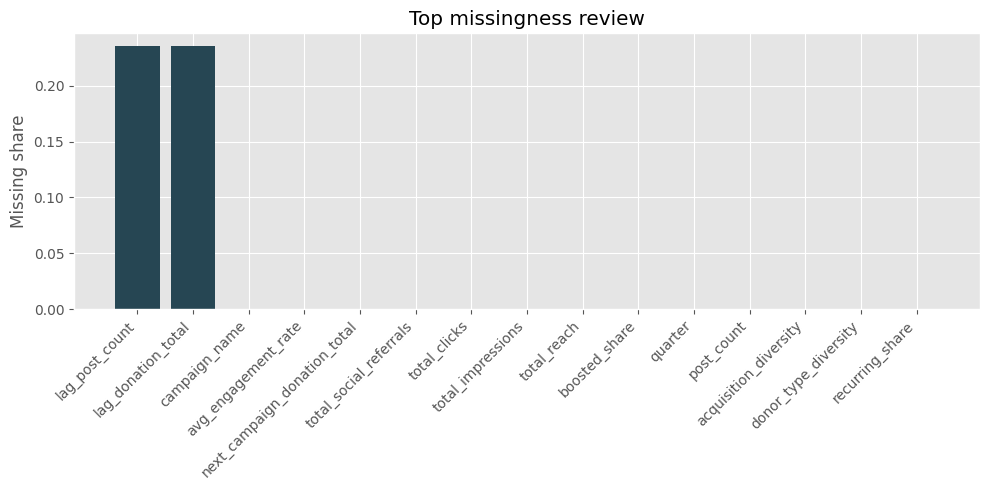

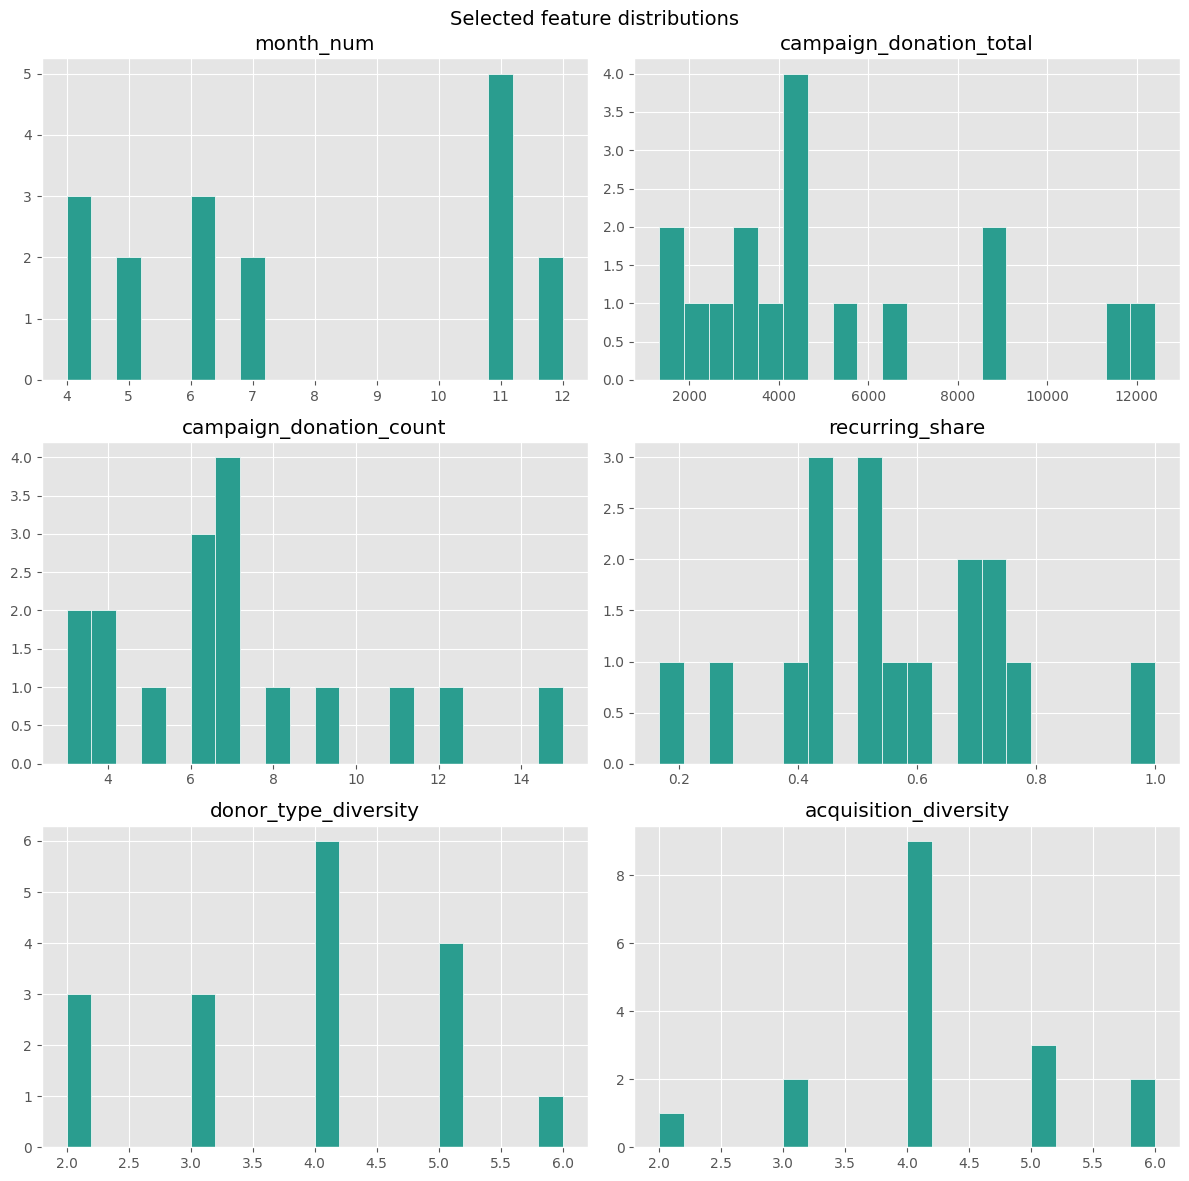

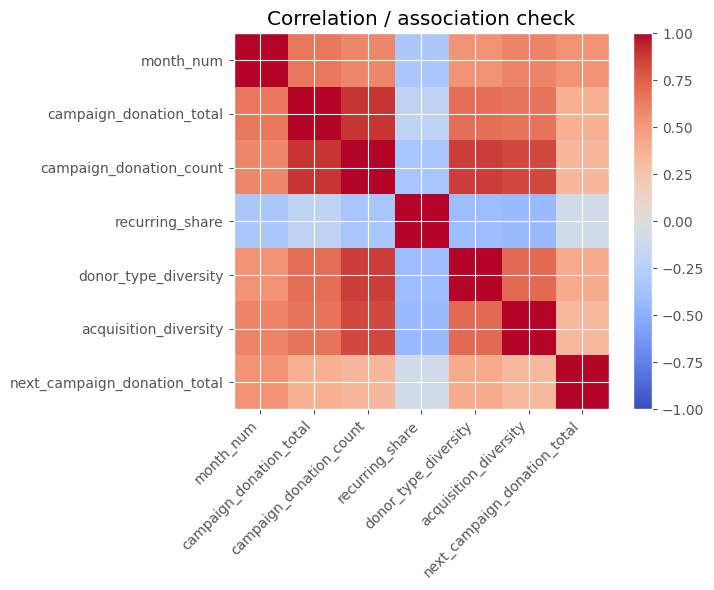

In [3]:
missing_table = cu.plot_missingness(df[feature_cols + [bundle["explanatory_target"], bundle["predictive_target"]]].copy(), "Top missingness review")
display(missing_table)

preview_numeric = [
    col
    for col in numeric_cols
    if col in df.columns and not pd.api.types.is_bool_dtype(df[col])
][:6]
if preview_numeric:
    cu.plot_numeric_overview(df, preview_numeric, "Selected feature distributions")

corr_candidates = [
    col
    for col in preview_numeric
    if pd.api.types.is_numeric_dtype(df[col]) and not pd.api.types.is_bool_dtype(df[col])
]
if bundle["predictive_target"] in df.columns and pd.api.types.is_numeric_dtype(df[bundle["predictive_target"]]):
    corr_candidates = corr_candidates + [bundle["predictive_target"]]
elif bundle["explanatory_target"] in df.columns and pd.api.types.is_numeric_dtype(df[bundle["explanatory_target"]]):
    corr_candidates = corr_candidates + [bundle["explanatory_target"]]

corr_candidates = list(dict.fromkeys([col for col in corr_candidates if col in df.columns]))
if len(corr_candidates) >= 3:
    corr = cu.plot_correlation_heatmap(df, corr_candidates, "Correlation / association check")
    display(corr.round(3))

if categorical_cols:
    cat = categorical_cols[0]
    print(f"Top categories for {cat}:")
    display(
        df[cat]
        .fillna("Missing")
        .value_counts()
        .head(10)
        .rename("count")
        .reset_index()
        .rename(columns={"index": cat})
    )

outlier_review = pd.DataFrame({
    "feature": preview_numeric,
    "p01": [pd.to_numeric(df[col], errors="coerce").quantile(0.01) for col in preview_numeric],
    "median": [pd.to_numeric(df[col], errors="coerce").median() for col in preview_numeric],
    "p99": [pd.to_numeric(df[col], errors="coerce").quantile(0.99) for col in preview_numeric],
})
display(outlier_review)


**Executive Takeaway.** The exploration stage verifies that the target and candidate drivers are measurable, identifies missingness patterns early, and checks whether the dataset grain matches the decision being modeled. Outliers are kept visible and interpreted, rather than silently discarded.


# 3. Modeling & Feature Selection

The feature set deliberately favors operationally available columns over every possible field in the raw tables. That matters for two reasons:

1. The website can only score records with fields it actually stores and can refresh.
2. IS 455 expects feature selection to be justified instead of treating the dataset as a dumping ground.

The explanatory model is chosen for interpretability. The predictive model is chosen for stronger out-of-sample performance and non-linear pattern capture where appropriate.


In [4]:
explanatory_results = cu.fit_and_evaluate_model(
    df=df,
    feature_cols=feature_cols,
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    target_col=bundle["explanatory_target"],
    kind=bundle["explanatory_kind"],
    role="explanatory",
    time_col=bundle["time_col"],
)

predictive_results = cu.fit_and_evaluate_model(
    df=df,
    feature_cols=feature_cols,
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    target_col=bundle["predictive_target"],
    kind=bundle["predictive_kind"],
    role="predictive",
    time_col=bundle["time_col"],
)

print("Explanatory model metrics")
display(explanatory_results["metrics"])
print("Predictive model metrics")
display(predictive_results["metrics"])

print("Top explanatory features")
display(explanatory_results["feature_table"])
print("Top predictive features")
display(predictive_results["feature_table"])


Explanatory model metrics


,test_rmse,test_mae,test_r2,cv_rmse_mean,cv_mae_mean,cv_r2_mean
0,5984.527001,5403.584667,-2.019132,4174.017558,3659.603022,-4.013948


Predictive model metrics


,test_rmse,test_mae,test_r2,cv_rmse_mean,cv_mae_mean,cv_r2_mean
0,3549.019402,2731.338453,-0.061791,3210.453863,2369.911156,-0.600636


Top explanatory features


,feature,effect,abs_effect
0,num__acquisition_diversity,2195.861117,2195.861117
1,num__campaign_donation_total,-2184.908398,2184.908398
2,cat__campaign_name_Year-End Hope,2048.037070,2048.037070
3,num__recurring_share,1677.996563,1677.996563
4,cat__campaign_name_GivingTuesday,-1518.621453,1518.621453
5,num__post_count,-1001.726856,1001.726856
6,num__donor_type_diversity,984.590053,984.590053
7,cat__campaign_name_Back to School,-904.315923,904.315923
8,num__boosted_share,-548.125811,548.125811
9,cat__quarter_2,-530.868766,530.868766


Top predictive features


,feature,effect,abs_effect
0,cat__campaign_name_Year-End Hope,0.308773,0.308773
1,num__lag_donation_total,0.134257,0.134257
2,num__avg_engagement_rate,0.095380,0.095380
3,num__boosted_share,0.072194,0.072194
4,num__total_clicks,0.068677,0.068677
5,num__post_count,0.051176,0.051176
6,num__total_social_referrals,0.050125,0.050125
7,num__recurring_share,0.036220,0.036220
8,num__campaign_donation_total,0.033201,0.033201
9,num__total_impressions,0.030691,0.030691


**Executive Takeaway.** Feature selection is anchored in business logic first and model diagnostics second. The explanatory model clarifies directional relationships, and the predictive model tests whether additional flexibility improves operational usefulness enough to justify lower interpretability.


# 4. Evaluation & Interpretation

Proper validation matters because this organization will act on the outputs. The notebook therefore uses train/test logic with cross-validation summaries rather than evaluating only on the full sample.

**Real-world error tradeoff.** False positives can send effort toward campaigns that underperform. False negatives can cause the organization to underfund a campaign that was about to gain momentum.



Explanatory model holdout sample preview


,next_campaign_donation_total,prediction,residual,split
0,12416.33,5992.462347,6423.867653,test
1,8545.69,3796.071426,4749.618574,test
2,4533.43,3556.956501,976.473499,test
3,5460.81,-3345.431523,8806.241523,test
4,2576.86,8638.582087,-6061.722087,test



Predictive model holdout sample preview


,next_campaign_donation_total,prediction,residual,split
0,12416.33,5919.141175,6497.188825,test
1,8545.69,6568.825090,1976.864910,test
2,4533.43,4469.570609,63.859391,test
3,5460.81,4270.947381,1189.862619,test
4,2576.86,6505.776520,-3928.916520,test


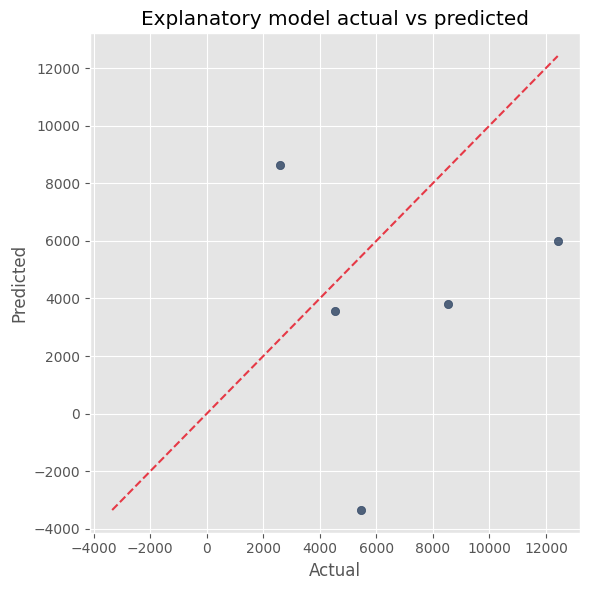

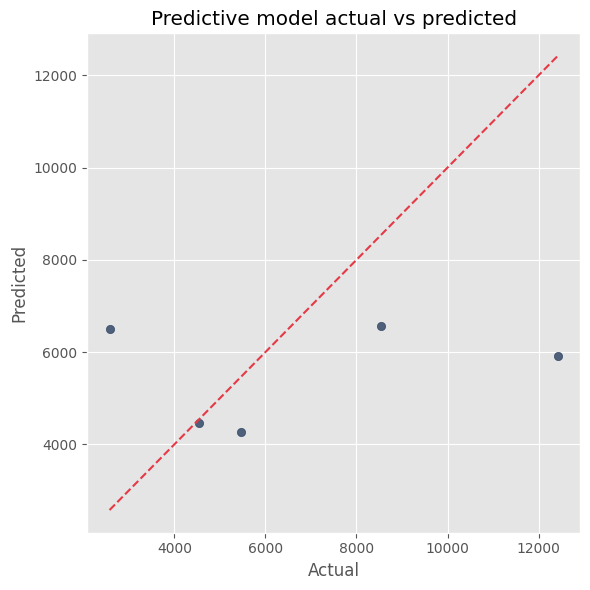

In [5]:
def show_model_diagnostics(label, results, kind, target_name):
    print(f"\n{label} holdout sample preview")
    display(results["holdout"].head(10))
    if kind == "classification":
        print(f"{label} confusion matrix")
        display(results["confusion_matrix"])
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.hist(results["holdout"]["score"], bins=15, color="#457b9d", edgecolor="white")
        ax.set_title(f"{label} holdout score distribution")
        ax.set_xlabel("Predicted probability")
        ax.set_ylabel("Count")
        plt.tight_layout()
    else:
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.scatter(results["holdout"][target_name], results["holdout"]["prediction"], alpha=0.75, color="#1d3557")
        lims = [
            np.nanmin([results["holdout"][target_name].min(), results["holdout"]["prediction"].min()]),
            np.nanmax([results["holdout"][target_name].max(), results["holdout"]["prediction"].max()]),
        ]
        ax.plot(lims, lims, linestyle="--", color="#e63946")
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")
        ax.set_title(f"{label} actual vs predicted")
        plt.tight_layout()

show_model_diagnostics("Explanatory model", explanatory_results, bundle["explanatory_kind"], bundle["explanatory_target"])
show_model_diagnostics("Predictive model", predictive_results, bundle["predictive_kind"], bundle["predictive_target"])


**Executive Takeaway.** The evaluation section is intentionally honest. If the holdout performance is only moderate, that still has value as a prioritization aid as long as the notebook states the limitation clearly and keeps humans in the loop for high-stakes decisions.


# 5. Causal and Relationship Analysis

This section distinguishes what is **predictive** from what is plausibly **explanatory**.

Boosted posts, reach, and clicks are useful signals, but they are still intertwined with campaign quality, timing, and audience fit, so causal claims should remain modest.

The tables below focus on the strongest modeled relationships while being careful not to equate feature importance with proof of causality.


In [6]:
relationship_target = bundle["predictive_target"] if bundle["predictive_kind"] == "regression" else bundle["explanatory_target"]
relationship_numeric = [col for col in numeric_cols if col in df.columns and df[col].notna().sum() > 5][:12]

if relationship_target in df.columns and pd.api.types.is_numeric_dtype(df[relationship_target]) and relationship_numeric:
    relationship_table = (
        df[relationship_numeric + [relationship_target]]
        .apply(pd.to_numeric, errors="coerce")
        .corr(numeric_only=True)[[relationship_target]]
        .sort_values(relationship_target, ascending=False)
    )
    display(relationship_table.round(3))

explanatory_top = explanatory_results["feature_table"].copy()
predictive_top = predictive_results["feature_table"].copy()
explanatory_top["model"] = "explanatory"
predictive_top["model"] = "predictive"
combined_top = pd.concat([explanatory_top, predictive_top], ignore_index=True)
display(combined_top)


,next_campaign_donation_total
next_campaign_donation_total,1.000
month_num,0.529
donor_type_diversity,0.400
total_clicks,0.387
campaign_donation_total,0.381
campaign_donation_count,0.336
acquisition_diversity,0.325
avg_engagement_rate,0.233
total_reach,0.132
total_impressions,0.126


,feature,effect,abs_effect,model
0,num__acquisition_diversity,2195.861117,2195.861117,explanatory
1,num__campaign_donation_total,-2184.908398,2184.908398,explanatory
2,cat__campaign_name_Year-End Hope,2048.037070,2048.037070,explanatory
3,num__recurring_share,1677.996563,1677.996563,explanatory
4,cat__campaign_name_GivingTuesday,-1518.621453,1518.621453,explanatory
5,num__post_count,-1001.726856,1001.726856,explanatory
6,num__donor_type_diversity,984.590053,984.590053,explanatory
7,cat__campaign_name_Back to School,-904.315923,904.315923,explanatory
8,num__boosted_share,-548.125811,548.125811,explanatory
9,cat__quarter_2,-530.868766,530.868766,explanatory


**Executive Takeaway.** The strongest drivers in the models are useful for strategy discussions, but they should be interpreted as structured evidence rather than causal proof. In this project, observational data is valuable for prioritization and learning even when it cannot support hard causal claims.


# 6. Deployment Notes

**Website integration path.** Display forecast cards on `/admin?tab=donations`, connect recommendations to `/admin?tab=outreach`, and support campaign comparisons on `/admin?tab=reports`.

**Likely API surface.** A lightweight backend endpoint such as `/api/ml/campaign-performance` can score new records or refresh dashboard aggregates on a schedule.

**Implementation sketch.**

```python
# pseudocode used by the web app or backend job
record_batch = load_latest_records_from_database()
scored = model.predict_or_predict_proba(record_batch)
write_scores_back_to_reporting_table(scored)
refresh_dashboard_cards()
```

**Repository alignment.** The current application already has pages for admin dashboard, donations, residents, reports, outreach, and impact, so this pipeline is designed to plug into those existing navigation surfaces instead of inventing a disconnected demo experience.


**Executive Takeaway.** A notebook-only model is not enough for the rubric. The practical endpoint of this work is a score, forecast, or explanatory summary that appears in the deployed web app where staff and donors can actually use it.
